# SHAP Analysis

In [16]:
# Cell 1 — path setup
import os, sys
os.chdir(r'D:\Dibimbing.Id\Supply Chain')
sys.path.insert(0, r'D:\Dibimbing.Id\Supply Chain')

In [17]:
# Cell 2 — load model yang sudah tersimpan
import joblib

best_final_s1 = {
    '_model': joblib.load('models/tuned_model_s1.pkl'),
    'Model' : 'tuned_model_s1',  # ganti sesuai nama model aslinya
}

best_final_s2 = {
    '_model': joblib.load('models/tuned_model_s2.pkl'),
    'Model' : 'tuned_model_s2',
}

print("Model S1:", type(best_final_s1['_model']).__name__)
print("Model S2:", type(best_final_s2['_model']).__name__)

Model S1: RandomForestClassifier
Model S2: ExtraTreesClassifier


In [18]:
# Cell 3 — load data
import pandas as pd
from src.features import prepare_all

df = pd.read_csv('dataset/DataCoSupplyChainDataset.csv', encoding='latin1')
data = prepare_all(df)

X_train_s1, X_test_s1 = data['s1']['X_train'], data['s1']['X_test']
y_train_s1, y_test_s1 = data['s1']['y_train'], data['s1']['y_test']

X_train_s2, X_test_s2 = data['s2']['X_train'], data['s2']['X_test']
y_train_s2, y_test_s2 = data['s2']['y_train'], data['s2']['y_test']

Fitur baru ditambahkan: discount_per_unit
OHE cols: ['Type']
Dtypes sebelum OHE: Type    str
dtype: object
OHE cols: ['Type', 'Order Region', 'Customer State']
Dtypes sebelum OHE: Type              str
Order Region      str
Customer State    str
dtype: object
Skenario 1 setelah encoding: (180519, 9)
Skenario 2 setelah encoding: (180519, 78)

--- Skenario 1 (Pre-Shipment) ---
Train: 144,415 | Test: 36,104 | Fitur: 8

--- Skenario 2 (Full Order Profile) ---
Train: 144,415 | Test: 36,104 | Fitur: 77


In [19]:
import importlib
import matplotlib.pyplot as plt
import src.shap as shap_mod
importlib.reload(shap_mod)
from src.shap import run_shap_analysis

## Skenario 1


SHAP Analysis — tuned_model_s1 — Skenario 1 (Pre-Shipment)


<Figure size 1000x600 with 0 Axes>

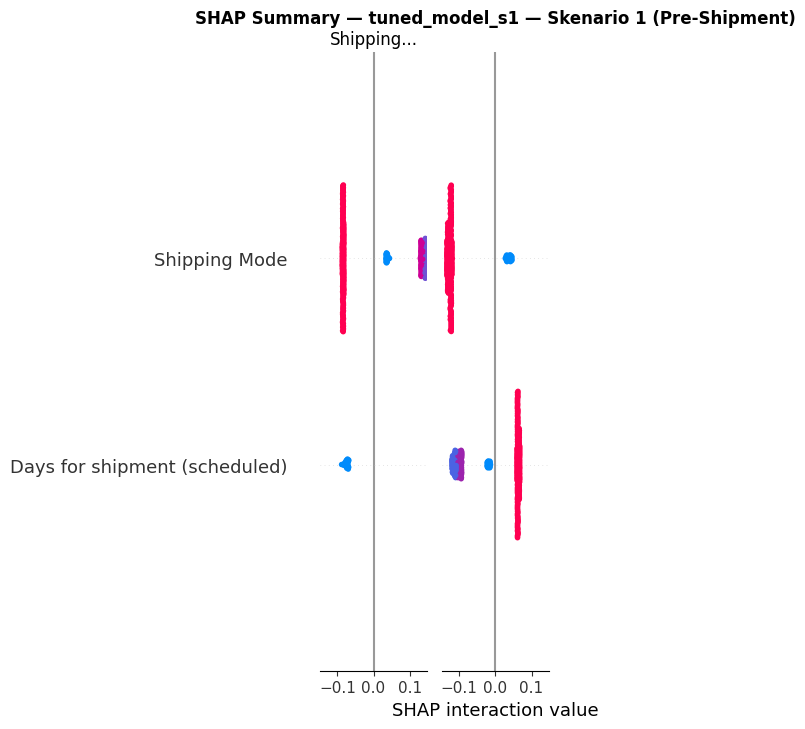

<Figure size 1000x600 with 0 Axes>

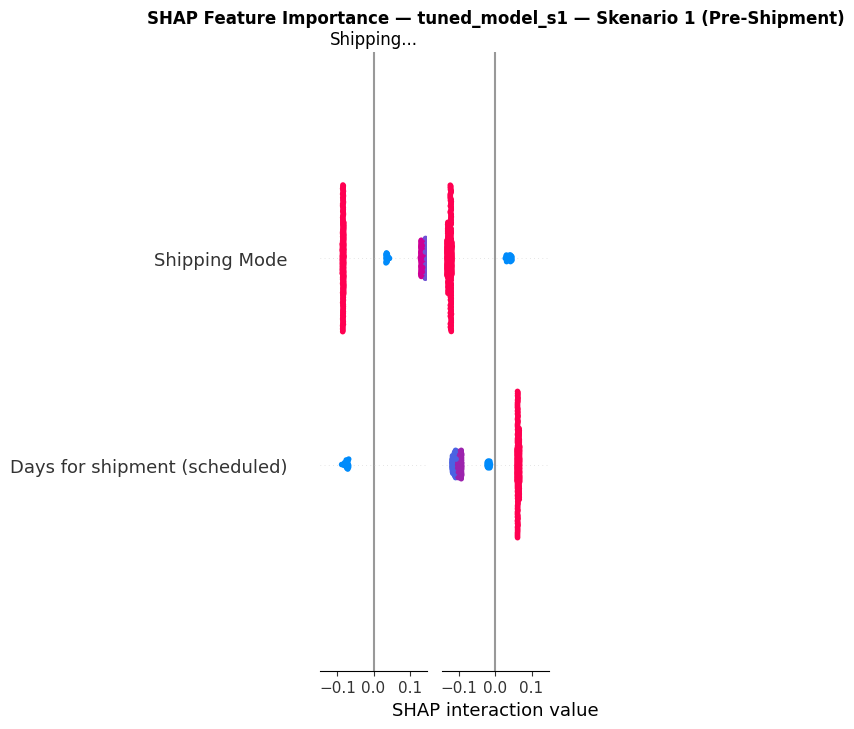

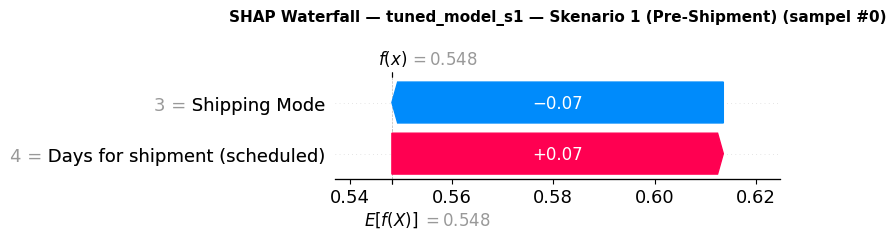

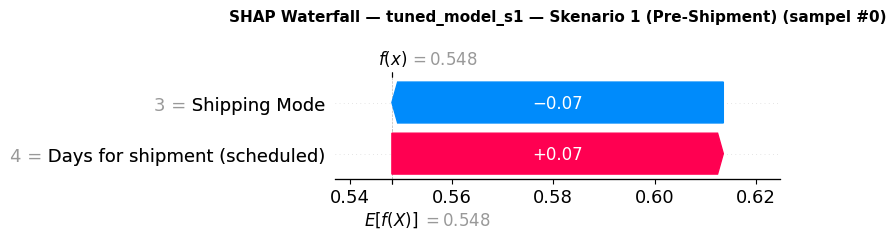


Top-10 Fitur berdasarkan SHAP:
                         Feature  Mean |SHAP|
1                  Shipping Mode     0.102598
2  Days for shipment (scheduled)     0.077016
3                  Type_TRANSFER     0.014732
4                     Type_DEBIT     0.006773
5                   Type_PAYMENT     0.003454
6                  Product Price     0.000614
7       Order Item Discount Rate     0.000587
8            Order Item Quantity     0.000362


In [20]:
shap_values_s1, top_features_s1 = run_shap_analysis(
    model   = best_final_s1['_model'],
    X_train = X_train_s1,
    X_test  = X_test_s1,
    label   = f"{best_final_s1['Model']} — Skenario 1 (Pre-Shipment)",
    n_sample= 500,
)


## Skenrio 2


SHAP Analysis — tuned_model_s2 — Skenario 2 (Full Order Profile)


<Figure size 1000x600 with 0 Axes>

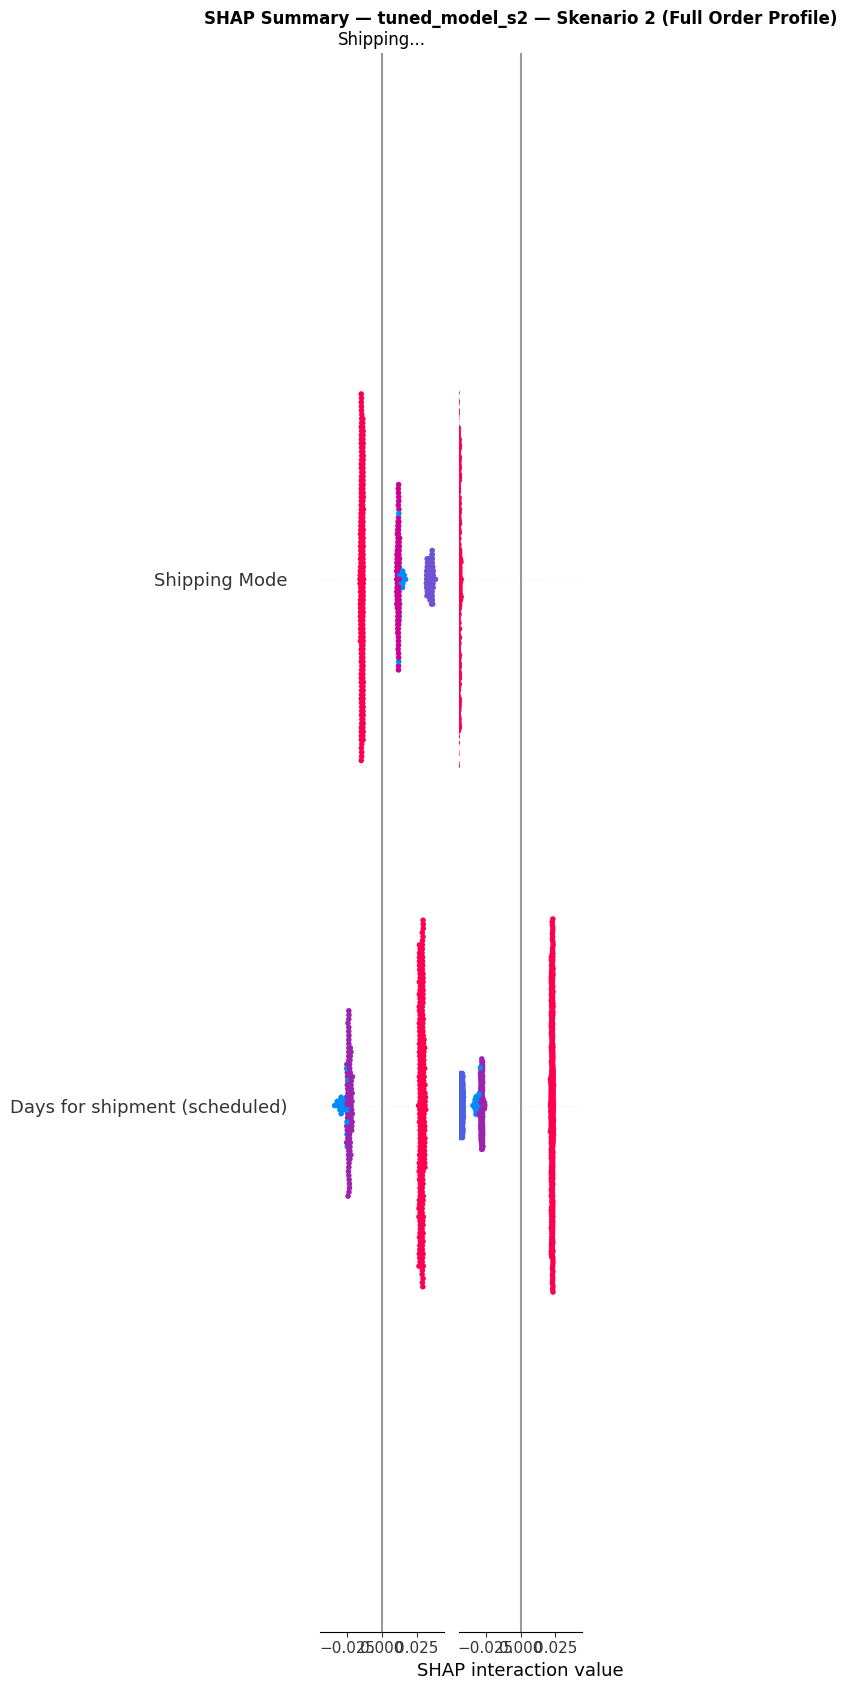

<Figure size 1000x600 with 0 Axes>

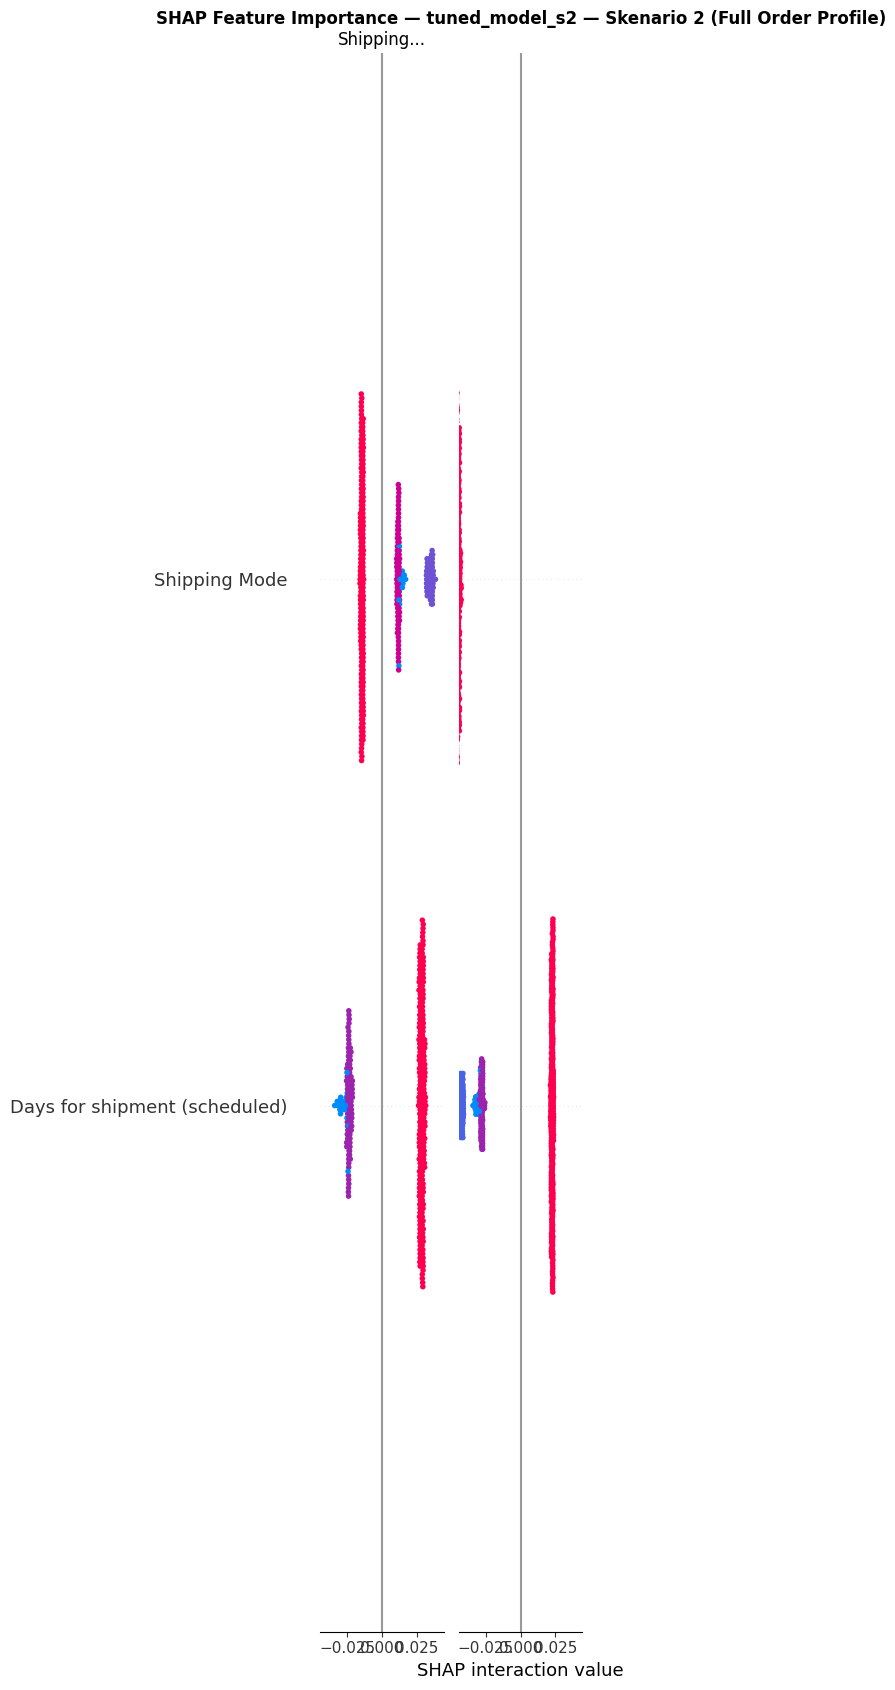

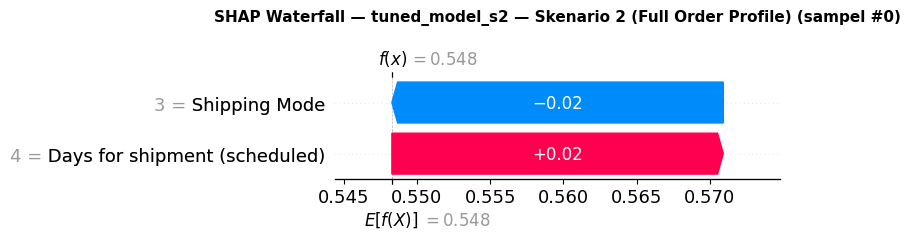

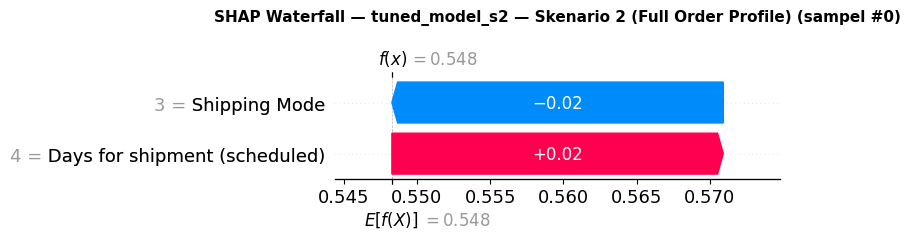


Top-10 Fitur berdasarkan SHAP:
                          Feature  Mean |SHAP|
1   Days for shipment (scheduled)     0.027873
2                   Shipping Mode     0.017455
3                   Type_TRANSFER     0.006606
4                      Type_DEBIT     0.002606
5                    Type_PAYMENT     0.001449
6     Order Region_Western Europe     0.000632
7          Order Region_Caribbean     0.000252
8               Customer State_CO     0.000165
9               Customer State_NY     0.000145
10              Customer State_NJ     0.000145


In [22]:
shap_values_s2, top_features_s2 = run_shap_analysis(
    model   = best_final_s2['_model'],
    X_train = X_train_s2,
    X_test  = X_test_s2,
    label   = f"{best_final_s2['Model']} — Skenario 2 (Full Order Profile)",
    n_sample= 500,
)

## Perbandingan 2 Skenario

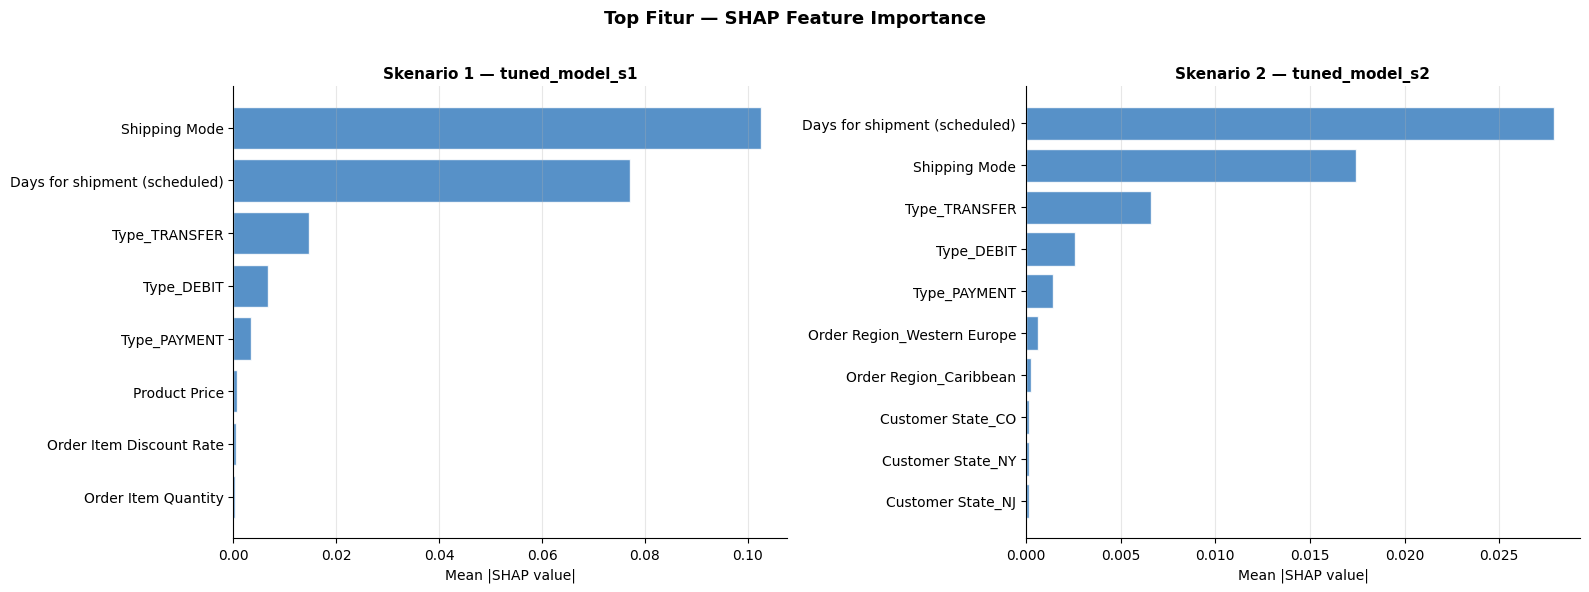

In [24]:
top10_s1 = top_features_s1.head(10).set_index('Feature')['Mean |SHAP|']
top10_s2 = top_features_s2.head(10).set_index('Feature')['Mean |SHAP|']
all_feats = list(dict.fromkeys(top10_s1.index.tolist() + top10_s2.index.tolist()))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, vals, title in zip(axes,
    [top10_s1, top10_s2],
    [f'Skenario 1 — {best_final_s1["Model"]}',
     f'Skenario 2 — {best_final_s2["Model"]}']):
    vals = vals.sort_values(ascending=True)
    ax.barh(vals.index, vals.values, color='#3A7EBF', alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean |SHAP value|')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Top Fitur — SHAP Feature Importance\n', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
